In [42]:
!pip install filterpy==1.4.5
!pip install lap==0.4.0

  Using cached lap-0.4.0.tar.gz (1.5 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for lap
  Running setup.py clean for lap
Failed to build lap
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (lap)


In [43]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import pandas as pd
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import cv2
import json
import matplotlib.patches as patches
from scipy.spatial import distance
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# Modify sort.py to remove the problematic matplotlib backend setting
!sed -i "s/matplotlib.use('TkAgg')/#matplotlib.use('TkAgg')/" /content/sort.py
!sed -i "s/import matplotlib.pyplot as plt/#import matplotlib.pyplot as plt/" /content/sort.py
!sed -i "s/import matplotlib.patches as patches/#import matplotlib.patches as patches/" /content/sort.py

In [46]:
#from ultralytics import YOLO
#
## Load a pretrained model (e.g., YOLOv8n)
#model = YOLO("yolov8n.pt")
#
## Train the model
#results = model.train(
#    data="/home/gcartasso/video cut/tennis ball detection.v6i.yolov11/data.yaml",
#    epochs=100,
#    imgsz=640,
#    batch=16,
#    project="custom_folder",  # Saves to 'custom_folder/train/'
#    name="my_model_exp1",     # Subfolder name
#)

In [47]:
# Load your trained model
model = YOLO("/content/drive/MyDrive/best.pt")  # Path to your trained weights
model_person = YOLO("yolov8n.pt")

In [48]:
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset
import torch
from torchvision import models, transforms
from PIL import Image

model_court = models.resnet50(pretrained=True)
model_court.fc =  torch.nn.Linear(model_court.fc.in_features, 14*2)
save_path = "/content/drive/MyDrive/best_model_noresize.pth"

import matplotlib.pyplot as plt
import torchvision.transforms as T
class ImagePreProcess:
    def __init__(self):
        # Define the transformation pipeline
        self.transforms = transforms.Compose([
            transforms.Resize((224, 224)),  # Resize to 224x224
            transforms.ToTensor(),  # Convert to tensor and scale to [0, 1]
        ])

    def __call__(self, img):
        """
        Process an image (can be OpenCV frame or PIL Image)
        """
        # Convert OpenCV BGR to PIL RGB if needed
        if isinstance(img, np.ndarray):
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(img_rgb)
        else:
            img_pil = img

        original_size = img_pil.size
        img_transform = self.transforms(img_pil)

        return img_pil, img_transform, original_size
model_court.load_state_dict(torch.load(save_path))
model_court.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [49]:
import cv2
import numpy as np
import pandas as pd
from sort import Sort  # Ensure SORT is installed
from ultralytics import YOLO  # Import YOLO from ultralytics
import os

# Load YOLO model
yolo = YOLO("/content/drive/MyDrive/best.pt")  # Use the YOLO class from ultralytics

# Initialize SORT tracker
tracker = Sort()
preprocessor = ImagePreProcess()
# Movement threshold
MOVEMENT_THRESHOLD = 0.5  # pixels

# Track previous positions
prev_positions = {}

# Output folder
os.makedirs("moving_frames", exist_ok=True)

# Initialize DataFrame
results_df = pd.DataFrame(columns=['frame', 'position x', 'position y', 'id object','court','player_1','player_2'])
colours_players = pd.DataFrame(columns=['player_1','player_2'])
position_players = pd.DataFrame(columns=['player_1','player_2'])
# Open video
cap = cv2.VideoCapture("/content/drive/MyDrive/IMG_5164.MOV")
frame_count = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_court.to(device)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

    # Run YOLO detection
    results = yolo.predict(frame,conf=0.1)
    detections = []
    boxes_player = []
    distance_centre = pd.DataFrame(columns=['distance'])
    image_centre = [frame.shape[0]//2,frame.shape[1]//2]
    for result in results:
      for number,box in enumerate(result.boxes.xyxy.tolist()):
        distance_centre.loc[number,'distance'] = distance.euclidean(image_centre,np.array(box[:2]))
    for result in results:
        for number,box in enumerate(result.boxes.xywh.tolist()):
          if number in distance_centre.sort_values(by='distance',ascending=True)[:2].index:
            boxes_player.append(box)
    if len(boxes_player)>=2:
      player_image_1 = frame[int(boxes_player[0][1]-boxes_player[0][3]/2):int(boxes_player[0][1]+boxes_player[0][3]/2),int(boxes_player[0][0]-boxes_player[0][2]/2):int(boxes_player[0][0]+boxes_player[0][2]/2)]
      player_image_2 = frame[int(boxes_player[1][1]-boxes_player[1][3]/2):int(boxes_player[1][1]+boxes_player[1][3]/2),int(boxes_player[1][0]-boxes_player[1][2]/2):int(boxes_player[1][0]+boxes_player[1][2]/2)]
      kmeans = KMeans(n_clusters=10,random_state=10)
      kmeans.fit(np.array(player_image_1).reshape((-1, 3)))
      colors_1 = kmeans.cluster_centers_
      kmeans.fit(np.array(player_image_2).reshape((-1, 3)))
      colors_2 = kmeans.cluster_centers_
      if len(colours_players)==0:
        colours_players.loc[0,'player_1'] = colors_1.flatten()
        colours_players.loc[0,'player_2'] = colors_2.flatten()
        position_players.loc[0,'player_1'] = boxes_player[0]
        position_players.loc[0,'player_2'] = boxes_player[1]
      else:
        if distance.euclidean(colours_players.loc[0,'player_1'],colors_2.flatten())<distance.euclidean(colours_players.loc[0,'player_1'],colors_2.flatten()):
          position_players.loc[0,'player_1'] = boxes_player[0]
          position_players.loc[0,'player_2'] = boxes_player[1]
        else:
          position_players.loc[0,'player_1'] = boxes_player[1]
          position_players.loc[0,'player_2'] = boxes_player[0]


    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            detections.append([x1, y1, x2, y2, conf])

    # Prepare detections for the tracker
    if detections: # Check if detections list is not empty
        detections_np = np.array(detections)
    else: # If no detections, create an empty array of the correct shape
        detections_np = np.empty((0, 5))


    # Update tracker
    tracked_objects = tracker.update(detections_np)

    for obj in tracked_objects:
        x1, y1, x2, y2, obj_id = obj
        center = ((x1 + x2) / 2, (y1 + y2) / 2)

        # Check movement
        if obj_id in prev_positions:
            prev_center = prev_positions[obj_id]
            movement = np.linalg.norm(np.array(center) - np.array(prev_center))

            if movement > MOVEMENT_THRESHOLD:
                image,img_transformed,original_size = preprocessor(frame)
                with torch.no_grad():
                  # Move the input tensor to the same device as the model
                  img_transformed = img_transformed.unsqueeze(0).to(device)
                  pred_keypoints = model_court(img_transformed).cpu().numpy()[0]
                # Log to DataFrame
                new_row = pd.DataFrame([{
                    'frame': frame_count,
                    'position x': center[0],
                    'position y': center[1],
                    'id object': obj_id,
                    'court':pred_keypoints,
                    'player_1': position_players.loc[0,'player_1'],
                    'player_2': position_players.loc[0,'player_2']
                }])
                results_df = pd.concat([results_df, new_row], ignore_index=True)

        # Update position
        prev_positions[obj_id] = center

cap.release()

# Save DataFrame to CSV
results_df.to_csv("moving_objects_log.csv", index=False)


0: 384x640 (no detections), 17.8ms
Speed: 2.6ms preprocess, 17.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 24.3ms
Speed: 2.2ms preprocess, 24.3ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 29.7ms
Speed: 6.0ms preprocess, 29.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 22.3ms
Speed: 4.8ms preprocess, 22.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 18.6ms
Speed: 9.8ms preprocess, 18.6ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 tennis ball, 12.8ms
Speed: 1.9ms preprocess, 12.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 18.3ms
Speed: 1.9ms preprocess, 18.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 26.8ms
Speed: 4.2ms preprocess, 26.8ms inf

/tmp/ipython-input-3652797228.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


Streaming output truncated to the last 5000 lines.
0: 384x640 1 tennis ball, 10.4ms
Speed: 5.0ms preprocess, 10.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 tennis ball, 17.5ms
Speed: 4.0ms preprocess, 17.5ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 tennis ball, 17.9ms
Speed: 2.8ms preprocess, 17.9ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 tennis ball, 14.1ms
Speed: 2.0ms preprocess, 14.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 tennis balls, 8.0ms
Speed: 3.9ms preprocess, 8.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 tennis balls, 24.0ms
Speed: 3.1ms preprocess, 24.0ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 tennis ball, 11.6ms
Speed: 5.9ms preprocess, 11.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.2m

In [50]:
results_df

,frame,position x,position y,id object,court,player_1,player_2
0,95,738.789148,571.886867,3212.0,"[54.277122, 67.7156, 167.1295, 67.351654, -9.2...","[737.9390869140625, 571.8441162109375, 22.4470...","[840.8770751953125, 343.42529296875, 19.499267..."
1,263,738.980122,572.612421,3219.0,"[53.63472, 67.30158, 166.91862, 66.953354, -9....","[737.9390869140625, 571.8441162109375, 22.4470...","[840.8770751953125, 343.42529296875, 19.499267..."
2,264,738.974830,572.294882,3219.0,"[53.629105, 67.190186, 166.98184, 66.84191, -9...","[737.9390869140625, 571.8441162109375, 22.4470...","[840.8770751953125, 343.42529296875, 19.499267..."
3,369,738.628565,570.589237,3229.0,"[53.83555, 67.05051, 167.13095, 66.70296, -9.1...","[738.669921875, 571.9525146484375, 22.19360351...","[1243.7540283203125, 503.439697265625, 23.0251..."
4,555,807.856518,399.784355,3309.0,"[53.882828, 66.37659, 166.02768, 66.009384, -6...","[724.74267578125, 413.7901611328125, 17.094848...","[791.3492431640625, 410.30059814453125, 17.807..."
...,...,...,...,...,...,...,...
8909,27654,594.260069,325.404777,7461.0,"[52.981285, 70.22457, 168.20952, 69.78874, -13...","[729.9642333984375, 255.65655517578125, 13.125...","[594.1649169921875, 325.3551025390625, 14.2187..."
8910,27655,594.421245,325.268156,7461.0,"[52.9892, 70.31019, 168.38028, 69.87436, -13.4...","[729.9216918945312, 255.31436157226562, 13.271...","[594.3870849609375, 325.1932067871094, 13.9614..."
8911,27656,594.615133,325.292074,7461.0,"[52.9602, 70.384605, 168.2306, 69.9489, -13.36...","[729.9931640625, 255.0340576171875, 13.5191650...","[594.6014404296875, 325.3092041015625, 13.7307..."
8912,27657,594.857728,325.445020,7461.0,"[52.794525, 70.47381, 168.24263, 70.032196, -1...","[729.9931640625, 255.0340576171875, 13.5191650...","[594.6014404296875, 325.3092041015625, 13.7307..."


<Axes: >

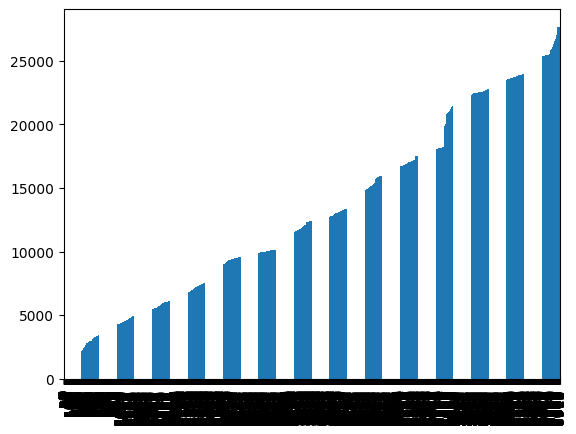

In [51]:
results_df.frame.plot(kind='bar')

In [52]:
video_path = '/content/drive/MyDrive/IMG_5164.MOV'

In [53]:
frames_per_second = cv2.VideoCapture(video_path).get(cv2.CAP_PROP_FPS)

In [54]:
frames_per_second

29.998429004548665

In [55]:
import numpy as np
whole_video=pd.DataFrame()
whole_video['all_frames'] = np.arange(0, results_df['frame'].max())

In [56]:
whole_video['video_frames'] = whole_video['all_frames'].apply(lambda x: 1 if x in results_df['frame'].to_list() else 0)

In [57]:
last_frames = []
new_video_frames = []
for i in whole_video['video_frames']:
    last_frames.append(i)
    if len(last_frames) > frames_per_second :
        last_frames = last_frames[-int(2*frames_per_second):]
        if (sum(last_frames) >=1):
            new_video_frames.append(1)
        else:
            new_video_frames.append(0)
    else:
        new_video_frames.append(0)
sum(new_video_frames)

22867

In [58]:
whole_video['video_frames'] = new_video_frames

In [59]:
whole_video = pd.merge(whole_video,results_df,how='left',right_on='frame',left_on='all_frames')

In [60]:
whole_video['test_frame'] = whole_video['video_frames']

In [61]:
interpolator_index = 0
position_x_interpolate = whole_video[whole_video['test_frame']==1]['position x'].interpolate(method='linear').to_list()
position_y_interpolate = whole_video[whole_video['test_frame']==1]['position y'].interpolate(method='linear').to_list()
for i in whole_video[whole_video['test_frame']==1].index:
    whole_video.loc[i,'position x'] = position_x_interpolate[interpolator_index]
    whole_video.loc[i,'position y'] = position_y_interpolate[interpolator_index]
    interpolator_index += 1

In [62]:
whole_video[whole_video['test_frame']==1]

,all_frames,video_frames,frame,position x,position y,id object,court,player_1,player_2,test_frame
95,95,1,95,738.789148,571.886867,3212.0,"[54.277122, 67.7156, 167.1295, 67.351654, -9.2...","[737.9390869140625, 571.8441162109375, 22.4470...","[840.8770751953125, 343.42529296875, 19.499267...",1
96,96,1,NaN,738.792385,571.899164,NaN,NaN,NaN,NaN,1
97,97,1,NaN,738.795622,571.911462,NaN,NaN,NaN,NaN,1
98,98,1,NaN,738.798859,571.923759,NaN,NaN,NaN,NaN,1
99,99,1,NaN,738.802096,571.936057,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...
28656,27653,1,27653,594.197507,325.485403,7461.0,"[53.64235, 70.07029, 167.69052, 69.63302, -12....","[730.2432861328125, 255.23361206054688, 13.076...","[594.1941528320312, 325.46844482421875, 14.130...",1
28657,27654,1,27654,594.260069,325.404777,7461.0,"[52.981285, 70.22457, 168.20952, 69.78874, -13...","[729.9642333984375, 255.65655517578125, 13.125...","[594.1649169921875, 325.3551025390625, 14.2187...",1
28658,27655,1,27655,594.421245,325.268156,7461.0,"[52.9892, 70.31019, 168.38028, 69.87436, -13.4...","[729.9216918945312, 255.31436157226562, 13.271...","[594.3870849609375, 325.1932067871094, 13.9614...",1
28659,27656,1,27656,594.615133,325.292074,7461.0,"[52.9602, 70.384605, 168.2306, 69.9489, -13.36...","[729.9931640625, 255.0340576171875, 13.5191650...","[594.6014404296875, 325.3092041015625, 13.7307...",1


In [63]:
whole_video['hit'] = False

In [64]:
hits = ((whole_video[whole_video['test_frame']==1]['position y'].rolling(window=int(frames_per_second),center=True).mean().diff() *
        whole_video[whole_video['test_frame']==1]['position y'].rolling(window=int(frames_per_second),center=True).mean().diff().shift(1)<0) &
        (whole_video[whole_video['test_frame']==1]['position y'].rolling(window=int(frames_per_second),center=True).mean().diff().shift(1).notna()))

In [65]:
whole_video.loc[hits.index,'hit'] = hits

In [66]:
whole_video[whole_video['hit']]['all_frames'].values[2]

663

In [67]:
import cv2

# Open the video file
cap = cv2.VideoCapture(video_path)

# Get the frame rate and total frames
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Total frames: {total_frames}, FPS: {fps}")

# Specify the target frame (0-based index)
target_frame = whole_video[whole_video['hit']]['all_frames'].values[18]  # Example: Stop at frame 100

# Read until the target frame
for frame_num in range(target_frame + 1):
    ret, frame = cap.read()
    if not ret:
        break
    if frame_num == target_frame:
        # Save the frame as an image
        cv2.imwrite("stopped_frame.jpg", frame)
        print(f"Stopped at frame {frame_num}")
        break

cap.release()

Total frames: 27688, FPS: 29.998429004548665
Stopped at frame 1515


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class KalmanFilter2D:
    def __init__(self, process_noise=0.01, measurement_noise=1):
        # State vector: [x, y, x_velocity, y_velocity]
        self.dt = 1.0  # Time step (adjust if your data isn't equally spaced)

        # State transition matrix (constant velocity model)
        self.F = np.array([[1, 0, self.dt, 0],
                           [0, 1, 0, self.dt],
                           [0, 0, 1, 0],
                           [0, 0, 0, 1]])

        # Measurement matrix (we only observe position)
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]])

        # Process noise covariance
        self.Q = np.eye(4) * process_noise

        # Measurement noise covariance
        self.R = np.eye(2) * measurement_noise

        # Initial state covariance (uncertainty)
        self.P = np.eye(4) * 100

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x[:2]

    def update(self, z):
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        y = z - self.H @ self.x
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.x[:2]

def apply_kalman_to_data(x_data, y_data, process_noise=0.01, measurement_noise=1):
    """
    Apply 2D Kalman filter to your X and Y data columns

    Parameters:
    x_data (array-like): Your X coordinate data
    y_data (array-like): Your Y coordinate data
    process_noise (float): Q parameter (higher = more responsive to changes)
    measurement_noise (float): R parameter (higher = smoother output)

    Returns:
    tuple: (filtered_x, filtered_y)
    """
    # Initialize Kalman filter
    kf = KalmanFilter2D(process_noise, measurement_noise)

    # Convert to numpy arrays if they aren't already
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    # Initialize with first measurement
    measurements = np.column_stack((x_data, y_data))
    kf.x = np.array([x_data[0], y_data[0], 0, 0])  # [x, y, vx, vy]

    # Run filter
    filtered_positions = []
    for z in measurements:
        kf.predict()
        filtered_positions.append(kf.update(z))

    filtered_positions = np.array(filtered_positions)
    return filtered_positions[:, 0], filtered_positions[:, 1]

# Example usage with your data:
# Assuming you have your data in a pandas DataFrame or two separate arrays

# METHOD 1: If you have a pandas DataFrame with 'x' and 'y' columns
# df = pd.read_csv('your_data.csv')  # Load your data
# filtered_x, filtered_y = apply_kalman_to_data(df['x'], df['y'])

# METHOD 2: If you have separate arrays
# x_data = [...]  # Your X coordinates
# y_data = [...]  # Your Y coordinates
# filtered_x, filtered_y = apply_kalman_to_data(x_data, y_data)

# To visualize results:
def plot_results(original_x, original_y, filtered_x, filtered_y):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(original_x, original_y, 'ro', markersize=4, alpha=0.5, label='Original')
    plt.plot(filtered_x, filtered_y, 'b-', linewidth=2, label='Filtered')
    plt.title('Trajectory Comparison')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(original_x, 'r-', alpha=0.5, label='Original X')
    plt.plot(original_y, 'g-', alpha=0.5, label='Original Y')
    plt.plot(filtered_x, 'b-', linewidth=2, label='Filtered X')
    plt.plot(filtered_y, 'm-', linewidth=2, label='Filtered Y')
    plt.title('Coordinate Values Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Position')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# After getting filtered_x, filtered_y:
# plot_results(x_data, y_data, filtered_x, filtered_y)

In [69]:
filtered_x, filtered_y = apply_kalman_to_data(whole_video[whole_video['test_frame']==1]['position x'], whole_video[whole_video['test_frame']==1]['position y'])

<Axes: >

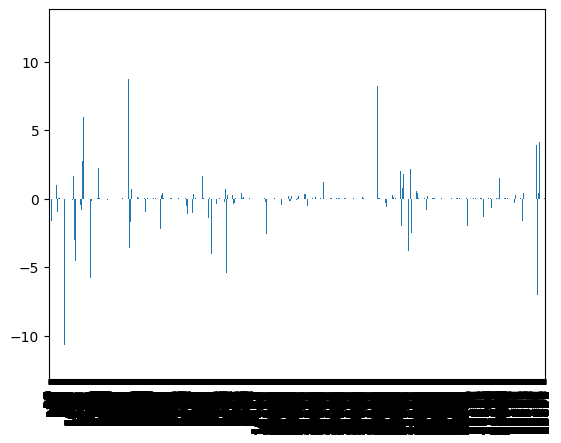

In [70]:
pd.Series(filtered_y).rolling(window=int(frames_per_second),center=True).mean().diff().plot.bar()

In [71]:
whole_video.loc[whole_video[whole_video['test_frame']==1].index,'position y'] = filtered_y

In [72]:
whole_video['hit'] = False

In [73]:
hits = ((whole_video[whole_video['test_frame']==1]['position y'].rolling(window=int(frames_per_second),center=True).mean().diff() *
        whole_video[whole_video['test_frame']==1]['position y'].rolling(window=int(frames_per_second),center=True).mean().diff().shift(1)<0) &
        (whole_video[whole_video['test_frame']==1]['position y'].rolling(window=int(frames_per_second),center=True).mean().diff().shift(1).notna()))

In [74]:
whole_video.loc[hits.index,'hit'] = hits

In [75]:
whole_video[whole_video['hit']]['all_frames'].values[4]

1281

In [76]:
last_hits = []
new_hits = []
for i in whole_video['hit'][::-1]:
    last_hits.append(i)
    if len(last_hits) > frames_per_second//2 :
        last_hits = last_hits[-int(frames_per_second//2):]
        if (sum(last_hits) ==1)&(i):
            new_hits.append(True)
        else:
            new_hits.append(False)
    else:
        new_hits.append(False)
new_hits.reverse()
sum(new_hits)

597

In [77]:
whole_video['new_hits'] = new_hits

In [78]:
whole_video[whole_video['new_hits']]

,all_frames,video_frames,frame,position x,position y,id object,court,player_1,player_2,test_frame,hit,new_hits
144,144,1,NaN,738.947753,572.489446,NaN,NaN,NaN,NaN,1,True,True
615,615,1,NaN,560.633867,360.835611,NaN,NaN,NaN,NaN,1,True,True
664,664,1,NaN,494.366372,400.827889,NaN,NaN,NaN,NaN,1,True,True
742,742,1,NaN,470.975260,340.476273,NaN,NaN,NaN,NaN,1,True,True
1281,1281,1,NaN,633.718755,403.270234,NaN,NaN,NaN,NaN,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
28273,27270,1,NaN,739.050899,571.899437,NaN,NaN,NaN,NaN,1,True,True
28475,27472,1,NaN,594.077960,325.777275,NaN,NaN,NaN,NaN,1,True,True
28499,27496,1,NaN,593.757385,325.777450,NaN,NaN,NaN,NaN,1,True,True
28608,27605,1,NaN,592.332622,325.868371,NaN,NaN,NaN,NaN,1,True,True


In [79]:
last_bounce = []
new_bounce = []
for i in whole_video['hit']:
    last_bounce.append(i)
    if len(last_bounce) > frames_per_second//2 :
        last_bounce = last_bounce[-int(frames_per_second//2):]
        if (sum(last_bounce) ==1)&(i):
            new_bounce.append(True)
        else:
            new_bounce.append(False)
    else:
        new_bounce.append(False)
sum(new_bounce)

597

In [80]:
whole_video['new_bounce'] = new_bounce

In [81]:
whole_video[whole_video['new_bounce']&whole_video['new_hits']]

,all_frames,video_frames,frame,position x,position y,id object,court,player_1,player_2,test_frame,hit,new_hits,new_bounce
144,144,1,NaN,738.947753,572.489446,NaN,NaN,NaN,NaN,1,True,True,True
615,615,1,NaN,560.633867,360.835611,NaN,NaN,NaN,NaN,1,True,True,True
664,664,1,NaN,494.366372,400.827889,NaN,NaN,NaN,NaN,1,True,True,True
742,742,1,NaN,470.975260,340.476273,NaN,NaN,NaN,NaN,1,True,True,True
1281,1281,1,NaN,633.718755,403.270234,NaN,NaN,NaN,NaN,1,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27966,26963,1,NaN,594.248672,326.291960,NaN,NaN,NaN,NaN,1,True,True,True
28273,27270,1,NaN,739.050899,571.899437,NaN,NaN,NaN,NaN,1,True,True,True
28475,27472,1,NaN,594.077960,325.777275,NaN,NaN,NaN,NaN,1,True,True,True
28608,27605,1,NaN,592.332622,325.868371,NaN,NaN,NaN,NaN,1,True,True,True


In [82]:
import cv2

def create_condensed_video(input_path, output_path, frames_to_keep):
    """
    Creates a condensed video from selected frames

    Args:
        input_path: Path to input video
        output_path: Path to save output video
        frames_to_keep: List or set of frame numbers to keep (0-based index)
    """
    cap = cv2.VideoCapture(input_path)

    # Get video properties from first frame
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Sort frames to keep in order
    frames_to_keep = sorted(set(frames_to_keep))

    # Create VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    current_frame = 0
    max_frame = max(frames_to_keep)

    while True:
        ret, frame = cap.read()
        if not ret or current_frame > max_frame:
            break

        if current_frame in frames_to_keep:
            out.write(frame)

        current_frame += 1

    cap.release()
    out.release()

# Example usage
frames_to_keep = whole_video[whole_video['test_frame']==1]['all_frames']
create_condensed_video('/content/drive/MyDrive/IMG_5164.MOV', '/content/drive/MyDrive/IMG_5164 condensed.MOV', frames_to_keep)